# 02. Exploratory Data Analysis: Sunny vs. Cloudy Sky Conditions & PV Power

**Stanford Solar Forecasting (SKIPP'D) Dataset**

---

### Objectives of this Notebook:

1. **Classify Sky Conditions:** Mathematically segment data into **Sunny (Clear Sky)**, **Partly Cloudy (High Ramp Volatility)**, and **Overcast / Cloudy** regimes using the **Clear-Sky Index ($k_t$)** and **Normalized Red-Blue Ratio (NRBR)**.
2. **Multimodal Computer Vision Analysis:** Extract optical and color features (RGB intensity, RBR, NRBR, cloud coverage fraction) from defisheyed sky images and compare across sky classes.
3. **PV Generation & Ramp Dynamics:** Analyze power distributions, diurnal profiles, and rapid ramp-rate fluctuations ($\Delta P_t$) driven by passing clouds.
4. **Cross-Modal Correlation:** Quantify how cloud optical properties and solar position directly govern PV electrical output.
5. **Continuous Day Case Studies:** Contrast full-day continuous time-series of sunny vs. volatile cloudy days with aligned sky camera frame sequences.


## 1. Setup & Dependencies


In [20]:
import os
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# Install pvlib if not present for astronomical solar position calculation
try:
    import pvlib
except ImportError:
    !pip install -q pvlib
    import pvlib

# Styling
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.size'] = 10
plt.rcParams['figure.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['axes.titlesize'] = 12

print("Libraries loaded successfully!")


Libraries loaded successfully!


## 2. Data Ingestion

We load the **defisheyed HDF5 dataset** (`2017_2019_images_pv_defisheye.hdf5`) or fall back to extracted `.npy` files. We use memory mapping to handle the large 4GB image array with minimal RAM footprint.


In [21]:
# Data search paths (handles Google Drive, Colab local, and workspace environments)
possible_hdf5_paths = [
    "/content/data/2017_2019_images_pv_defisheye.hdf5",
    "/content/drive/MyDrive/solar_data/2017_2019_images_pv_defisheye.hdf5",
]

hdf5_path = None
for p in possible_hdf5_paths:
    if os.path.exists(p):
        hdf5_path = p
        break

# Extracted directory fallback
data_dir = (
    "/content/data/extracted/" if os.path.exists("/content/data/extracted/") else "./"
)

if hdf5_path:
    print(f"Loading directly from HDF5: {hdf5_path}")
    f_h5 = h5py.File(hdf5_path, "r")
    trainval_images = f_h5["trainval"]["images_log"]
    trainval_pv = np.array(f_h5["trainval"]["pv_log"])
    test_images = f_h5["test"]["images_log"]
    test_pv = np.array(f_h5["test"]["pv_log"])
else:
    print("Loading from extracted .npy files...")
    # Try defisheyed first, then processed
    tv_img_p = os.path.join(data_dir, "trainval_images_defisheye.npy")
    if not os.path.exists(tv_img_p):
        tv_img_p = os.path.join(data_dir, "trainval_images_log.npy")
    trainval_images = np.load(tv_img_p, mmap_mode="r")
    trainval_pv = np.load(os.path.join(data_dir, "trainval_pv_log.npy"))

    te_img_p = os.path.join(data_dir, "test_images_defisheye.npy")
    if not os.path.exists(te_img_p):
        te_img_p = os.path.join(data_dir, "test_images_log.npy")
    test_images = np.load(te_img_p, mmap_mode="r")
    test_pv = np.load(os.path.join(data_dir, "test_pv_log.npy"))

# Load timestamps
for t_path in [
    "/content/data/times_trainval.npy",
    "/content/drive/MyDrive/solar_data/times_trainval.npy",
    "times_trainval.npy",
]:
    if os.path.exists(t_path):
        trainval_times = pd.to_datetime(np.load(t_path, allow_pickle=True))
        break
else:
    trainval_times = None

for t_path in [
    "/content/data/times_test.npy",
    "/content/drive/MyDrive/solar_data/times_test.npy",
    "times_test.npy",
]:
    if os.path.exists(t_path):
        test_times = pd.to_datetime(np.load(t_path, allow_pickle=True))
        break
else:
    test_times = None

print("=" * 60)
print(f"Train/Val Images: {trainval_images.shape} | PV: {trainval_pv.shape}")
print(f"Test Images:     {test_images.shape} | PV: {test_pv.shape}")
if trainval_times is not None:
    print(f"Train/Val Dates:  {trainval_times[0]} to {trainval_times[-1]}")
if test_times is not None:
    print(f"Test Dates:       {test_times[0]} to {test_times[-1]}")
print("=" * 60)

Loading directly from HDF5: /content/data/2017_2019_images_pv_defisheye.hdf5
Train/Val Images: (349372, 64, 64, 3) | PV: (349372,)
Test Images:     (14003, 64, 64, 3) | PV: (14003,)
Train/Val Dates:  2017-03-09 06:47:00 to 2019-10-26 17:59:20
Test Dates:       2017-09-15 07:11:00 to 2019-10-19 18:15:30


## 3. Solar Geometry & Clear-Sky Modeling

To classify sky conditions scientifically, we compute:

1. **Solar Zenith Angle ($\theta_z$) & Azimuth ($\gamma_s$)** using Stanford's geographical coordinates ($37.4275^\circ\text{N}, -122.170^\circ\text{W}$).
2. **Theoretical Clear-Sky PV Capacity ($P_{\text{clear}}$)**: Modeled via clear-sky global horizontal irradiance (GHI) scaled to the 30 kW rooftop array.
3. **Clear-Sky Index ($k_t$)**:
   $$k_t = \frac{P_t}{P_{\text{clear}, t}}$$
4. **Ramp Volatility Index ($R_t$)**:
   $$R_t = |P_t - P_{t-1}|$$


In [22]:
STANFORD_LAT = 37.4275
STANFORD_LON = -122.1700
STANFORD_TZ = "America/Los_Angeles"
PV_SYSTEM_CAPACITY_KW = 29.58  # Empirical peak generation for the 30-kW Stanford array


def compute_solar_features(pv_array, timestamps=None):
    """Computes Solar Zenith angle, Clear-sky capacity (p_clear), Clear-sky
    index (k_t), and 1-minute ramp-rate (R_t) for each timestep.
    """
    N = len(pv_array)
    df = pd.DataFrame({"pv": pv_array})

    if timestamps is not None and len(timestamps) == N:
        df["timestamp"] = pd.to_datetime(timestamps)
        times_dt = pd.DatetimeIndex(df["timestamp"])

        # Try pvlib first; if unavailable, use robust astronomical numpy formula
        try:
            import pvlib

            if times_dt.tz is None:
                times_localized = times_dt.tz_localize(STANFORD_TZ)
            else:
                times_localized = times_dt

            solpos = pvlib.solarposition.get_solarposition(
                times_localized, STANFORD_LAT, STANFORD_LON
            )
            df["zenith"] = solpos["zenith"].values
            df["azimuth"] = solpos["azimuth"].values

            # Haurwitz clear-sky model (purely geometric, no external turbidity tables needed)
            cs = pvlib.clearsky.haurwitz(solpos["apparent_zenith"])
            ghi_clear = cs["ghi"].values

            # Clear-sky PV power envelope (scaled to array capacity)
            p_clear = np.minimum(
                PV_SYSTEM_CAPACITY_KW,
                (ghi_clear / 1000.0) * PV_SYSTEM_CAPACITY_KW * 1.05,
            )
            df["p_clear"] = np.maximum(0.2, p_clear)
        except Exception as e:
            # Pure NumPy astronomical fallback
            doy = times_dt.dayofyear.values
            decl = 23.45 * np.sin(np.deg2rad(360.0 / 365.0 * (doy - 81)))
            b = np.deg2rad(360.0 / 364.0 * (doy - 81))
            eot = 9.87 * np.sin(2 * b) - 7.53 * np.cos(b) - 1.5 * np.sin(b)
            hours = times_dt.hour.values + times_dt.minute.values / 60.0
            lstm = 15.0 * (-8.0)  # PST = UTC-8
            tc = 4.0 * (STANFORD_LON - lstm) + eot
            lst = hours + tc / 60.0
            hra = 15.0 * (lst - 12.0)

            lat_rad = np.deg2rad(STANFORD_LAT)
            decl_rad = np.deg2rad(decl)
            hra_rad = np.deg2rad(hra)
            cos_zenith = np.sin(lat_rad) * np.sin(decl_rad) + np.cos(lat_rad) * np.cos(
                decl_rad
            ) * np.cos(hra_rad)
            cos_zenith = np.clip(cos_zenith, 0.0, 1.0)
            df["zenith"] = np.rad2deg(np.arccos(cos_zenith))
            df["azimuth"] = 180.0
            df["p_clear"] = np.maximum(0.2, PV_SYSTEM_CAPACITY_KW * (cos_zenith**1.1))
    else:
        # Slicing fallback
        df["zenith"] = 45.0
        df["azimuth"] = 180.0
        df["p_clear"] = 25.0

    # Clear-Sky Index k_t
    df["k_t"] = np.clip(df["pv"] / df["p_clear"], 0.0, 1.5)

    # 1-minute ramp rate (|ΔP_t| in kW/min)
    df["ramp_rate"] = np.abs(df["pv"].diff().fillna(0.0))

    return df


print("Computing solar geometry and clear-sky index for Train/Val...")
df_tv = compute_solar_features(trainval_pv, trainval_times)
print("Computing solar geometry and clear-sky index for Test...")
df_te = compute_solar_features(test_pv, test_times)
print("Solar features computed successfully!")

Computing solar geometry and clear-sky index for Train/Val...
Computing solar geometry and clear-sky index for Test...
Solar features computed successfully!


## 4. Sky Condition Classification (Sunny vs. Cloudy)

We categorize each observation into **three distinct atmospheric regimes**:

1. ☀️ **Sunny (Clear Sky):** $k_t \ge 0.85$ and low volatility ($R_t \le 1.0\,\text{kW/min}$). Unobstructed sun with high, steady generation.
2. ⛅ **Partly Cloudy (High Ramp Volatility):** $0.40 \le k_t < 0.85$ or $R_t > 1.0\,\text{kW/min}$. Moving cumulus clouds causing severe intermittency.
3. ☁️ **Overcast / Cloudy:** $k_t < 0.40$. Heavy, diffuse cloud cover with severe attenuation.


/tmp/ipykernel_50891/2216633461.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts_tv.index, y=counts_tv.values, ax=axes[0], palette=palette)
/tmp/ipykernel_50891/2216633461.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts_te.index, y=counts_te.values, ax=axes[1], palette=palette)


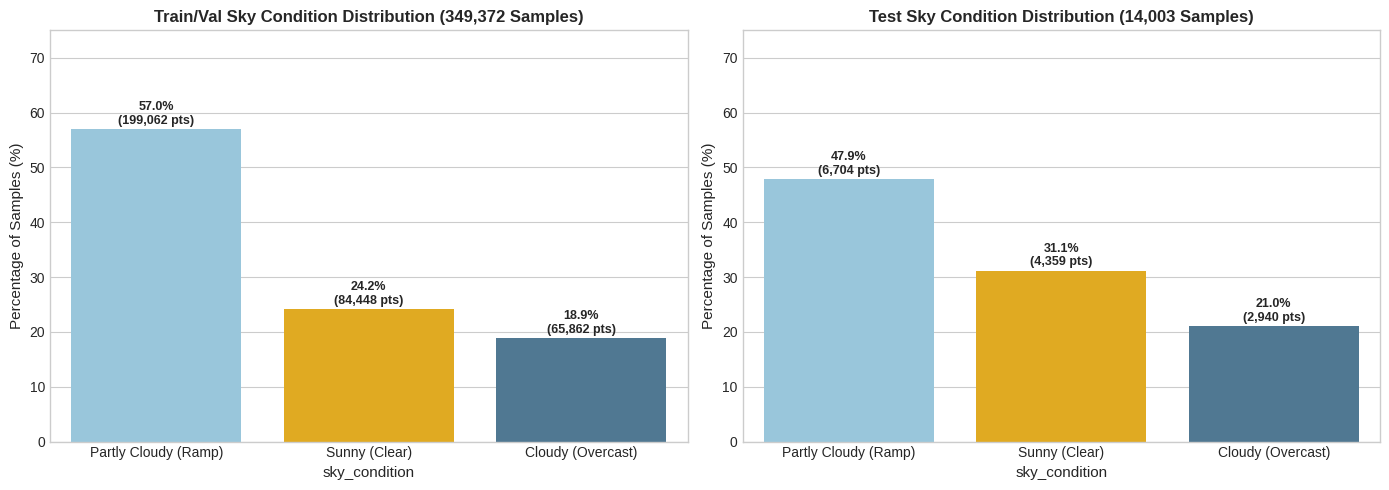

In [23]:
def classify_sky_condition(row):
    if row["k_t"] >= 0.85 and row["ramp_rate"] <= 1.0:
        return "Sunny (Clear)"
    elif row["k_t"] < 0.40:
        return "Cloudy (Overcast)"
    else:
        return "Partly Cloudy (Ramp)"


df_tv["sky_condition"] = df_tv.apply(classify_sky_condition, axis=1)
df_te["sky_condition"] = df_te.apply(classify_sky_condition, axis=1)

# Summary Statistics Table
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

palette = {
    "Sunny (Clear)": "#ffb703",
    "Partly Cloudy (Ramp)": "#8ecae6",
    "Cloudy (Overcast)": "#457b9d",
}

# Train/Val Breakdown
counts_tv = df_tv["sky_condition"].value_counts(normalize=True) * 100
sns.barplot(x=counts_tv.index, y=counts_tv.values, ax=axes[0], palette=palette)
axes[0].set_title(
    "Train/Val Sky Condition Distribution (349,372 Samples)", fontweight="bold"
)
axes[0].set_ylabel("Percentage of Samples (%)")
for i, v in enumerate(counts_tv.values):
    axes[0].text(
        i,
        v + 1,
        f"{v:.1f}%\n({int(df_tv['sky_condition'].value_counts()[counts_tv.index[i]]):,} pts)",
        ha="center",
        fontweight="bold",
        fontsize=9,
    )
axes[0].set_ylim(0, 75)

# Test Breakdown
counts_te = df_te["sky_condition"].value_counts(normalize=True) * 100
sns.barplot(x=counts_te.index, y=counts_te.values, ax=axes[1], palette=palette)
axes[1].set_title("Test Sky Condition Distribution (14,003 Samples)", fontweight="bold")
axes[1].set_ylabel("Percentage of Samples (%)")
for i, v in enumerate(counts_te.values):
    axes[1].text(
        i,
        v + 1,
        f"{v:.1f}%\n({int(df_te['sky_condition'].value_counts()[counts_te.index[i]]):,} pts)",
        ha="center",
        fontweight="bold",
        fontsize=9,
    )
axes[1].set_ylim(0, 75)

plt.tight_layout()
plt.show()

## 5. Computer Vision & Sky Image Feature Analysis

We extract key optical metrics from the sky camera frames:

- **Mean RGB Intensity:** Overall sky brightness.
- **Normalized Red-Blue Ratio (NRBR):** $\text{NRBR} = \frac{R - B}{R + B + \epsilon}$. Clear blue skies have high blue channel values (negative NRBR), while white/gray clouds scatter red and blue equally (higher/positive NRBR).
- **Cloud Coverage Fraction:** Percentage of pixels exceeding the cloud threshold ($\text{NRBR} > -0.15$).


### 5.1 Visual Sky Image Gallery: Sunny vs. Partly Cloudy vs. Overcast

Direct comparison of sky camera images and their concurrent PV power generation across the three classes.


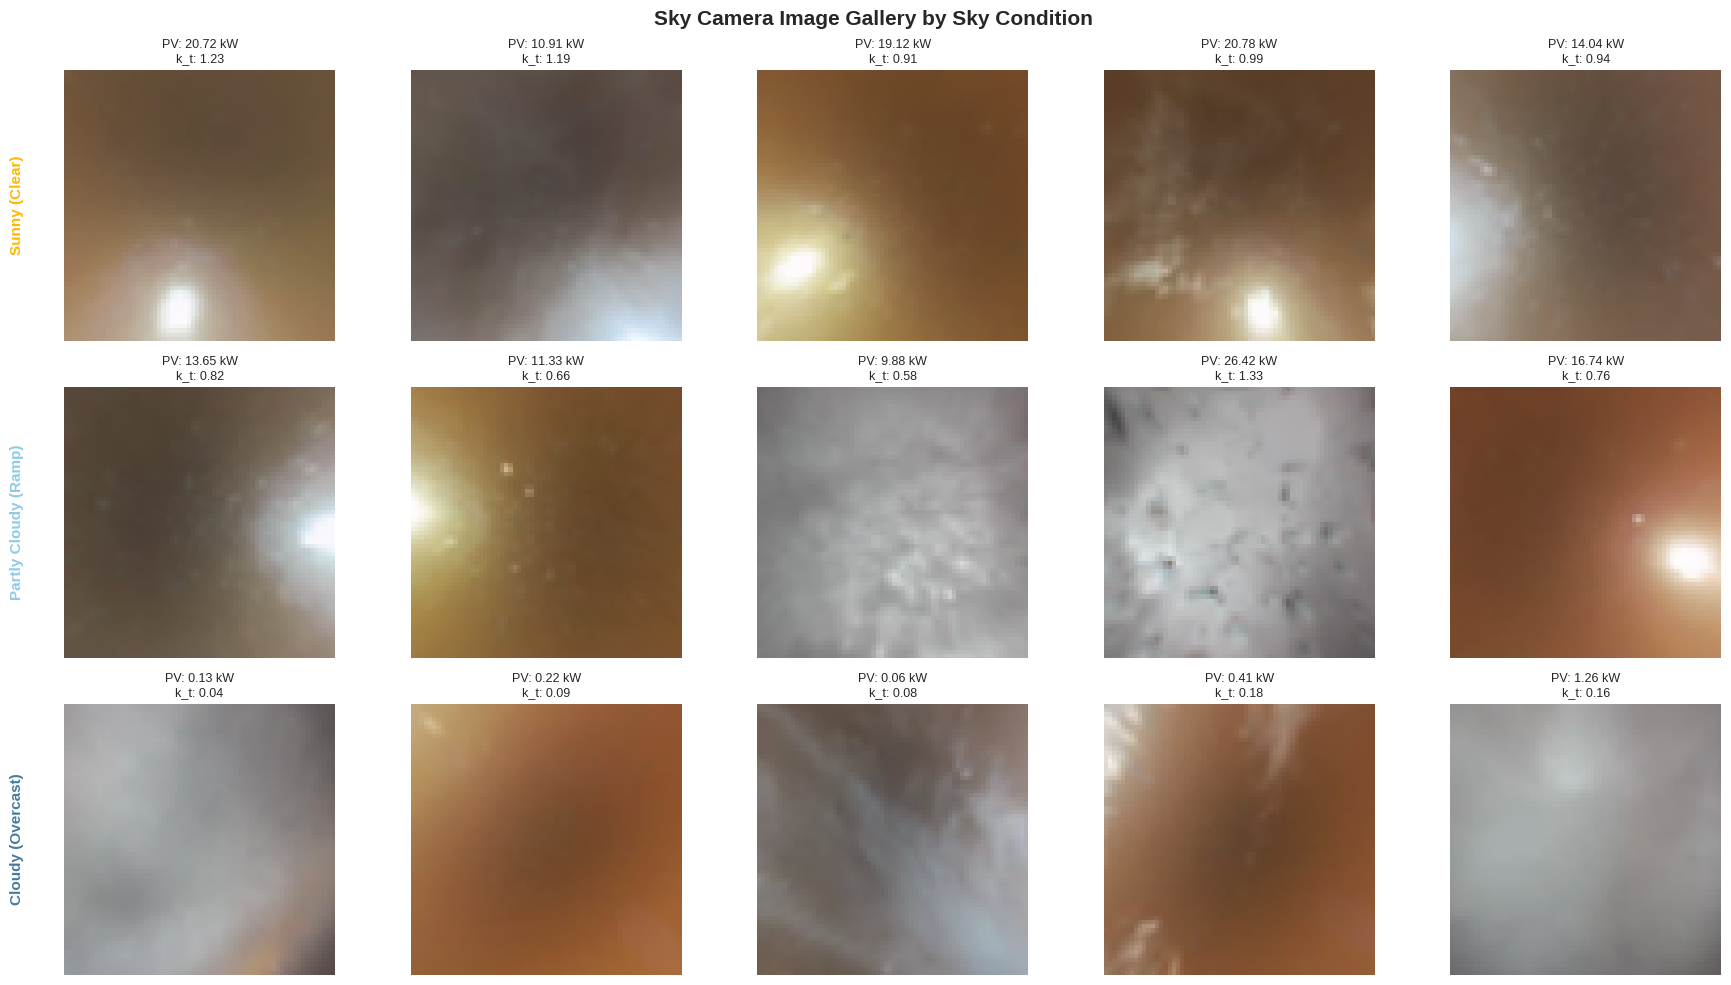

In [24]:
def format_img(img):
    if img.ndim == 3 and img.shape[0] == 3:
        img = np.transpose(img, (1, 2, 0))
    if img.max() > 1.0 and img.dtype != np.uint8:
        img = img / 255.0
    return img


classes = ["Sunny (Clear)", "Partly Cloudy (Ramp)", "Cloudy (Overcast)"]
num_samples_per_class = 5

fig, axes = plt.subplots(3, num_samples_per_class, figsize=(18, 10))
fig.suptitle(
    "Sky Camera Image Gallery by Sky Condition", fontsize=15, fontweight="bold", y=0.98
)

for row_idx, cls_name in enumerate(classes):
    cls_indices = df_tv[df_tv["sky_condition"] == cls_name].index
    chosen = np.random.choice(cls_indices, size=num_samples_per_class, replace=False)

    for col_idx, idx in enumerate(chosen):
        ax = axes[row_idx, col_idx]
        ax.imshow(format_img(trainval_images[idx]))
        pv_val = df_tv.loc[idx, "pv"]
        kt_val = df_tv.loc[idx, "k_t"]
        ax.set_title(f"PV: {pv_val:.2f} kW\nk_t: {kt_val:.2f}", fontsize=9)
        ax.axis("off")

    axes[row_idx, 0].text(
        -0.2,
        0.5,
        cls_name,
        transform=axes[row_idx, 0].transAxes,
        fontsize=11,
        fontweight="bold",
        va="center",
        rotation="vertical",
        color=palette[cls_name],
    )

plt.tight_layout()
plt.show()

## 6. PV Power Generation & Ramp Dynamics

We analyze how PV power generation behavior changes under each condition:

- **Distribution density** (Violin & KDE plots).
- **Diurnal Hourly Profiles** (Morning-to-evening trajectory), **Ramp-Rate Severity** ($|\Delta P_t|$ distribution under sunny vs. partly cloudy regimes).


/tmp/ipykernel_50891/3702170923.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


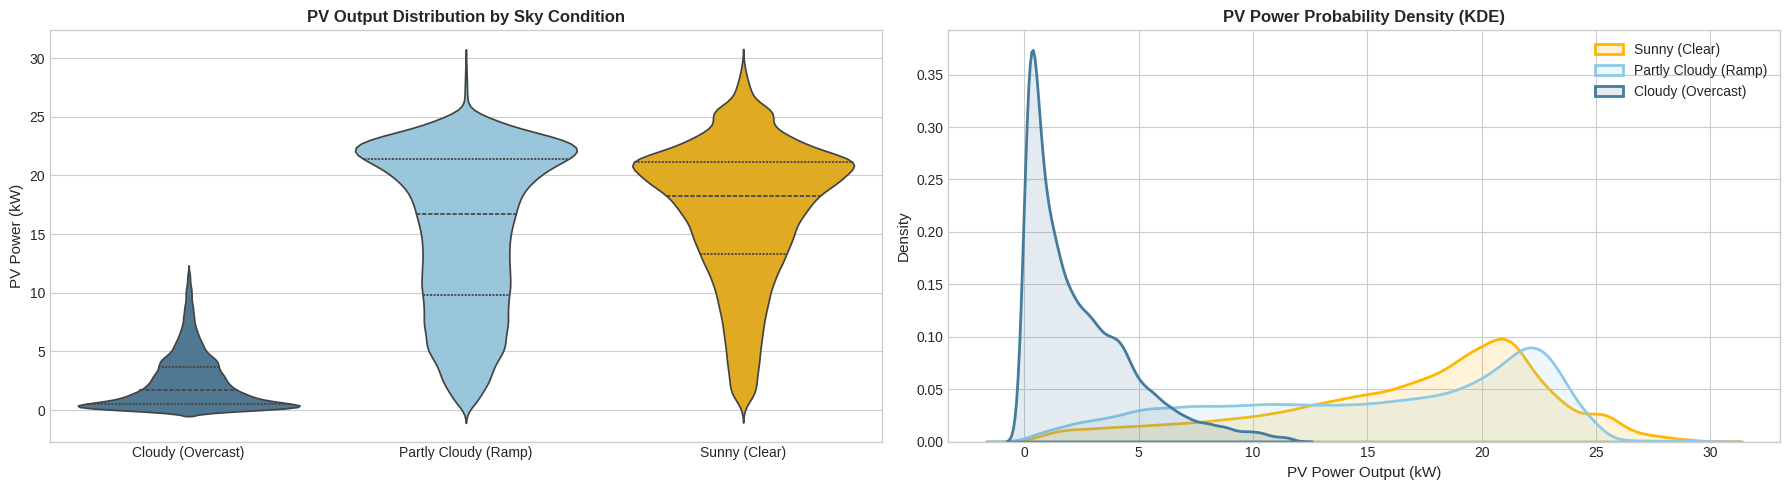

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# 1. Violin Plot of PV Power
sns.violinplot(
    data=df_tv, x="sky_condition", y="pv", palette=palette, ax=axes[0], inner="quartile"
)
axes[0].set_title("PV Output Distribution by Sky Condition", fontweight="bold")
axes[0].set_ylabel("PV Power (kW)")
axes[0].set_xlabel("")

# 2. KDE Density Comparison
for cls_name in classes:
    subset = df_tv[df_tv["sky_condition"] == cls_name]["pv"]
    sns.kdeplot(
        subset,
        ax=axes[1],
        label=cls_name,
        color=palette[cls_name],
        linewidth=2,
        fill=True,
        alpha=0.15,
    )
axes[1].set_title("PV Power Probability Density (KDE)", fontweight="bold")
axes[1].set_xlabel("PV Power Output (kW)")
axes[1].set_ylabel("Density")
axes[1].legend()


plt.tight_layout()
plt.show()

## 7. Cross-Modal Correlation Matrix

Quantifying the statistical relationships connecting **Sky Image Features (Brightness, NRBR, Cloud Fraction)**, **Solar Geometry (Zenith Angle)**, and **PV Power Output**.


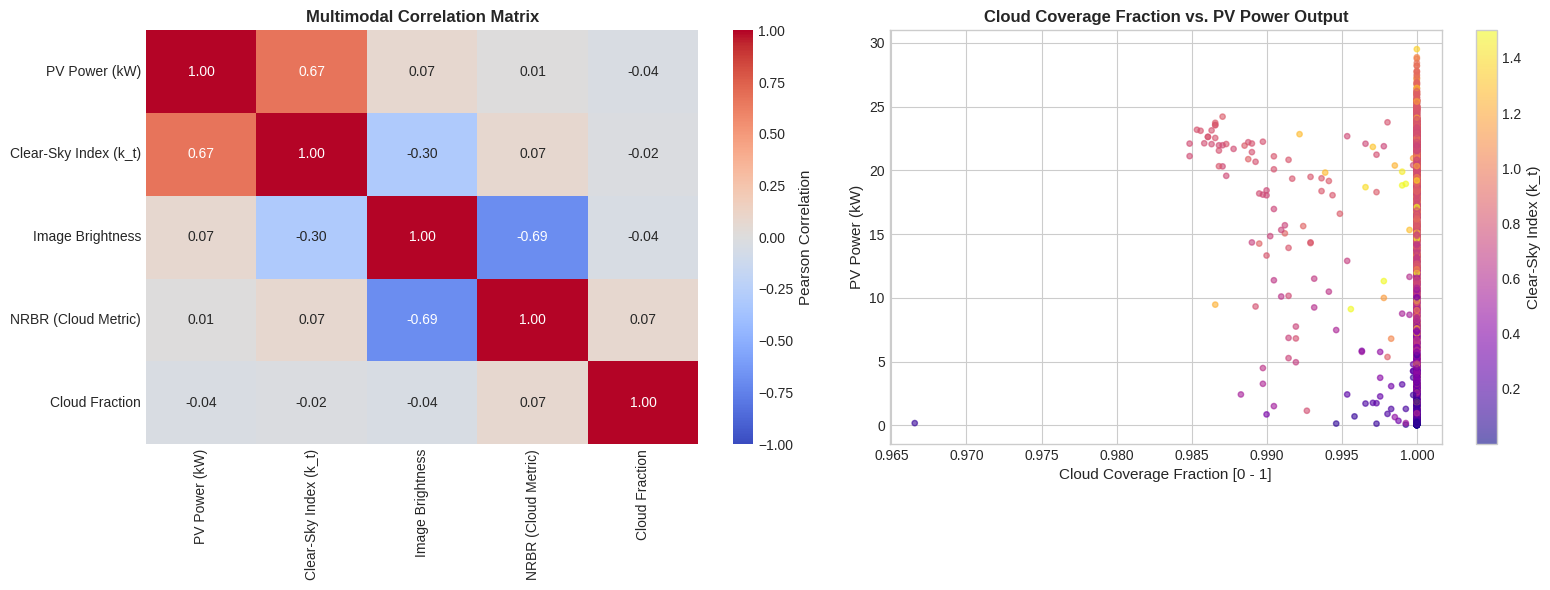

In [26]:
corr_cols = ["pv", "k_t", "mean_intensity", "mean_nrbr", "cloud_coverage"]
corr_df = (
    img_metrics_df[corr_cols]
    .rename(
        columns={
            "pv": "PV Power (kW)",
            "k_t": "Clear-Sky Index (k_t)",
            "mean_intensity": "Image Brightness",
            "mean_nrbr": "NRBR (Cloud Metric)",
            "cloud_coverage": "Cloud Fraction",
        }
    )
    .corr()
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap
sns.heatmap(
    corr_df,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    fmt=".2f",
    ax=axes[0],
    cbar_kws={"label": "Pearson Correlation"},
)
axes[0].set_title("Multimodal Correlation Matrix", fontweight="bold")

# Scatter: Cloud Coverage vs PV Power colored by k_t
sc = axes[1].scatter(
    img_metrics_df["cloud_coverage"],
    img_metrics_df["pv"],
    c=img_metrics_df["k_t"],
    cmap="plasma",
    alpha=0.6,
    s=15,
)
cbar = plt.colorbar(sc, ax=axes[1])
cbar.set_label("Clear-Sky Index (k_t)")
axes[1].set_title("Cloud Coverage Fraction vs. PV Power Output", fontweight="bold")
axes[1].set_xlabel("Cloud Coverage Fraction [0 - 1]")
axes[1].set_ylabel("PV Power (kW)")

plt.tight_layout()
plt.show()

## 8. Continuous Day Case Studies: Sunny vs. Ramp Cloudy Day

We inspect full continuous days from the dataset:

1. **Case Study 1: Clean Sunny Day:** Smooth, deterministic parabolic trajectory following the clear-sky model.
2. **Case Study 2: Volatile Partly Cloudy Day:** Severe intermittency, rapid power drops of $>15\,\text{kW}$ in minutes, with matching cloud camera frames.


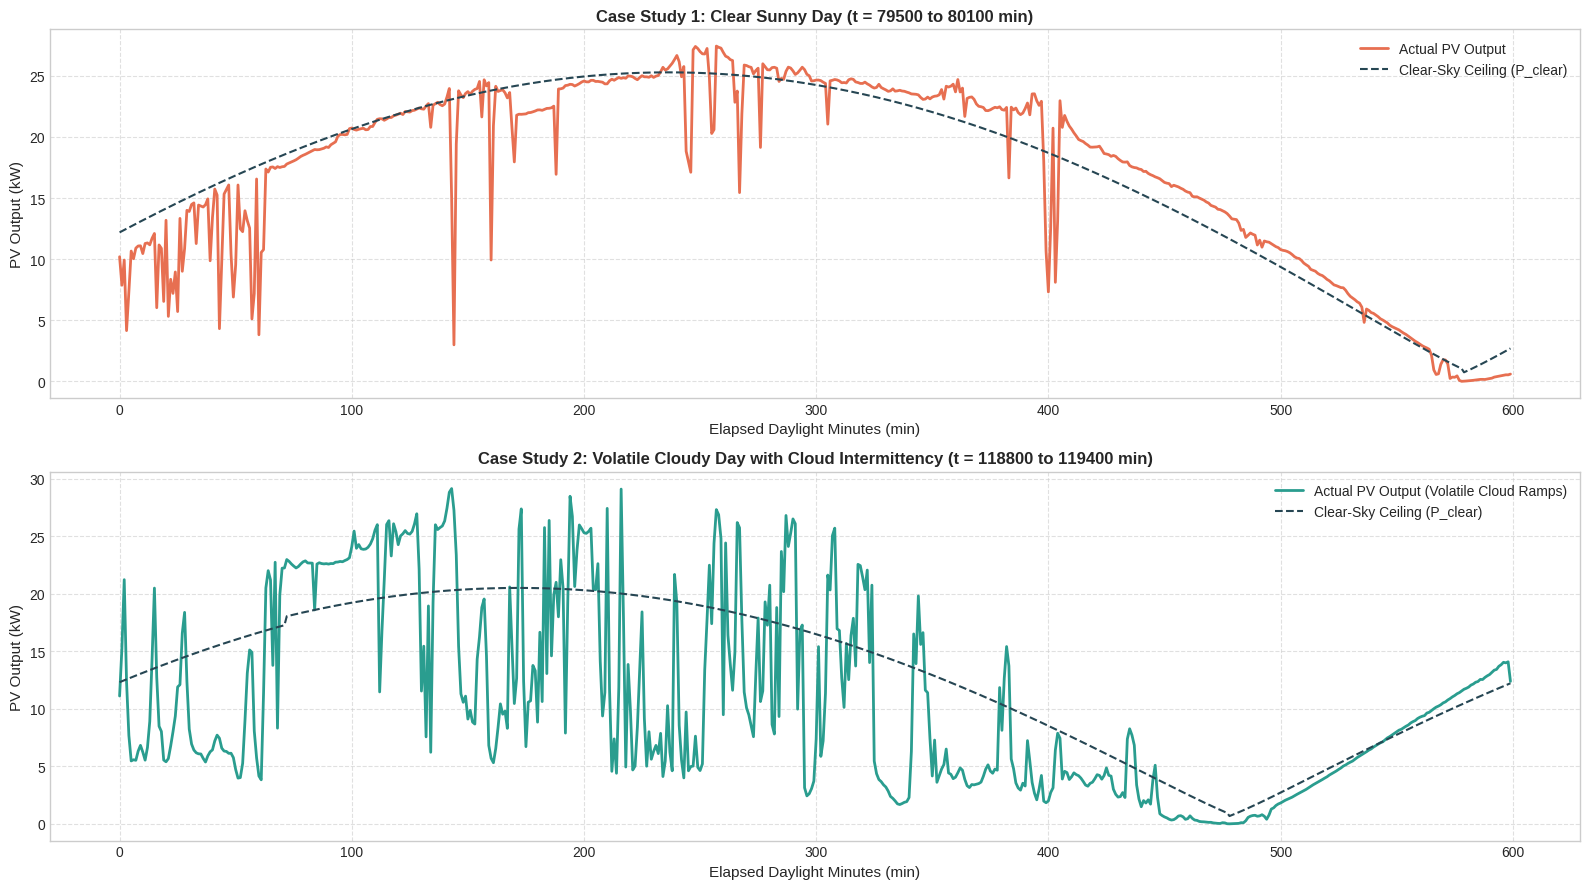

In [27]:
# Identify a classic sunny day slice and a high-ramp cloudy day slice
window = 600  # ~10 hours of daylight

# Find sunny slice (high mean kt, low std ramp)
kt_roll_mean = df_tv["k_t"].rolling(window, step=300).mean().dropna()
ramp_roll_std = df_tv["ramp_rate"].rolling(window, step=300).std().dropna()

sunny_start_idx = (
    int(kt_roll_mean[kt_roll_mean > 0.95].index[0]) - window
    if any(kt_roll_mean > 0.95)
    else 10000
)
cloudy_start_idx = (
    int(ramp_roll_std.nlargest(5).index[0]) - window
    if len(ramp_roll_std) > 0
    else 50000
)

fig, axes = plt.subplots(2, 1, figsize=(16, 9))

# Sunny Day Plot
t_sunny = np.arange(window)
axes[0].plot(
    t_sunny,
    df_tv.loc[sunny_start_idx : sunny_start_idx + window - 1, "pv"].values,
    color="#e76f51",
    linewidth=2,
    label="Actual PV Output",
)
axes[0].plot(
    t_sunny,
    df_tv.loc[sunny_start_idx : sunny_start_idx + window - 1, "p_clear"].values,
    color="#264653",
    linestyle="--",
    linewidth=1.5,
    label="Clear-Sky Ceiling (P_clear)",
)
axes[0].set_title(
    f"Case Study 1: Clear Sunny Day (t = {sunny_start_idx} to {sunny_start_idx+window} min)",
    fontweight="bold",
    fontsize=12,
)
axes[0].set_ylabel("PV Output (kW)")
axes[0].set_xlabel("Elapsed Daylight Minutes (min)")
axes[0].grid(True, linestyle="--", alpha=0.6)
axes[0].legend(loc="upper right")

# Cloudy Ramp Day Plot
t_cloudy = np.arange(window)
axes[1].plot(
    t_cloudy,
    df_tv.loc[cloudy_start_idx : cloudy_start_idx + window - 1, "pv"].values,
    color="#2a9d8f",
    linewidth=2,
    label="Actual PV Output (Volatile Cloud Ramps)",
)
axes[1].plot(
    t_cloudy,
    df_tv.loc[cloudy_start_idx : cloudy_start_idx + window - 1, "p_clear"].values,
    color="#264653",
    linestyle="--",
    linewidth=1.5,
    label="Clear-Sky Ceiling (P_clear)",
)
axes[1].set_title(
    f"Case Study 2: Volatile Cloudy Day with Cloud Intermittency (t = {cloudy_start_idx} to {cloudy_start_idx+window} min)",
    fontweight="bold",
    fontsize=12,
)
axes[1].set_ylabel("PV Output (kW)")
axes[1].set_xlabel("Elapsed Daylight Minutes (min)")
axes[1].grid(True, linestyle="--", alpha=0.6)
axes[1].legend(loc="upper right")

plt.tight_layout()
plt.show()